In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special 
import random

# 5.1 Exact Results

In [173]:
Jc = 0.5*np.log(1+np.sqrt(2))

def m(J):
    m = np.zeros(len(J))
    for t in range(len(J)):
        Jc = 0.5*np.log(1+np.sqrt(2))
        if J[t] > Jc:
            m[t] = (1- 1/(np.sinh(2*J[t])**4))**(1/8)
        else:
            m[t] = 0
    return m

def coth(x):
    return np.cosh(x)/np.sinh(x)

def sech(x):
    return 1/np.cosh(x)

def epsilon(J):
    return -J*coth(2*J)*(1+ 2/np.pi*(2*np.tanh(2*J)**2-1)*scipy.special.ellipk(4*sech(2*J)**2*np.tanh(2*J)**2))

In [23]:
# Control
j = np.array([0.25,1,2,3])
print(m(1/j),epsilon(1/j))

[1.         0.99927575 0.91131938 0.        ] [-8.         -1.9971602  -0.87278229 -0.27243653]


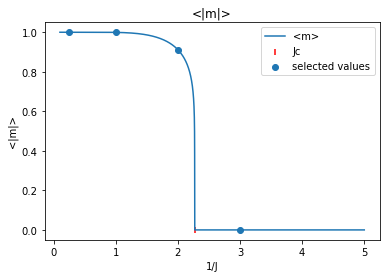

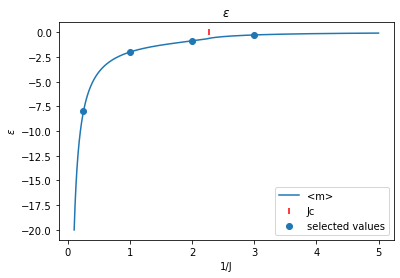

In [128]:
J_minus_1 = np.linspace(0.1,5,10000)
plt.plot(J_minus_1,m(1/J_minus_1), label = '<m>')
plt.scatter(x= 1/Jc, y=0, color="red", clip_on=False, marker ='|', label='Jc')
plt.scatter(j,[1.,0.99927575 ,0.91131938, 0.], label ='selected values')
plt.legend()
plt.title('<|m|>')
plt.xlabel('1/J')
plt.ylabel('<|m|>')
plt.show()
plt.plot(J_minus_1,epsilon(1/J_minus_1), label = '<m>')
plt.scatter(x= 1/Jc, y=0, color="red", clip_on=False, marker ='|', label='Jc')
plt.scatter(j,[-8. ,-1.9971602 , -0.87278229 ,-0.27243653], label ='selected values')
plt.legend()
plt.title('$\epsilon$')
plt.xlabel('1/J')
plt.ylabel('$\epsilon$')
plt.show()

# 5.2 MCMC for the 2D Ising Model

In [11]:
# Same for H1d, np.roll for all four directions

def H2d(J,x):
    return -J*(np.roll(x,-1, axis=1)*x + np.roll(x,1, axis=1)*x +np.roll(x,-1, axis=0)*x + np.roll(x,1, axis=0)*x).sum()

In [13]:
def delH2d(J,sigma,x):
    a = x[0]
    b = x[1]
    delH = 0
    if a == len(sigma)-1:
        delH = sigma[a,b]*sigma[a-1,b] + sigma[a,b]*sigma[0,b]
    else:
        delH = sigma[a,b]*sigma[a-1,b] + sigma[a,b]*sigma[a+1,b]
    if b == len(sigma.T)-1:
        delH = delH + sigma[a,b]*sigma[a,b-1] + sigma[a,b]*sigma[a,0]
    else:
        delH = delH + sigma[a,b]*sigma[a,b-1] + sigma[a,b]*sigma[a,b+1]
        
    return 2*J*delH

In [119]:
# wie ist epsilon definiert??

def MC_right(J,start,steps):
    # start with distribution "start"
    current = start
    m = np.zeros(steps)
    m_abs = np.zeros(steps)
    eps = np.zeros(steps)

    
    for s in range(steps):
        #for each step choose position
        x = np.random.choice(len(start), 2)

        if np.random.uniform(low=0, high=1) < np.exp(-delH2d(J,current,x)): # accepting condition
            # if accepted flip a spin
            new = current
            new[x[0],x[1]] = -current[x[0],x[1]]

        else:
            # else keep current spinconfiguration
            new = current
        current = new
        #calculate M/N
        
        m[s] = current.sum()/(len(start))**2
        m_abs[s] = np.abs(m[s])
        eps[s] = H2d(J,current)/(2*(len(start))**2)

    return m, m_abs, eps

In [120]:
# N_{4,8,12} contains m, m_abs ,epsilon

sigma_4 = np.ones((4,4))
N_4 = MC_right(0.5,sigma_4,10000)
sigma_8 = np.ones((8,8))
N_8 = MC_right(0.5,sigma_8,10000)
sigma_12 = np.ones((12,12))
N_12 = MC_right(0.5,sigma_12,10000)

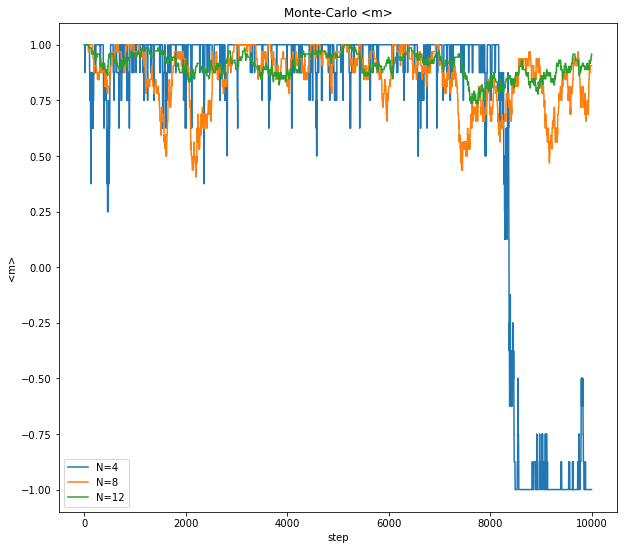

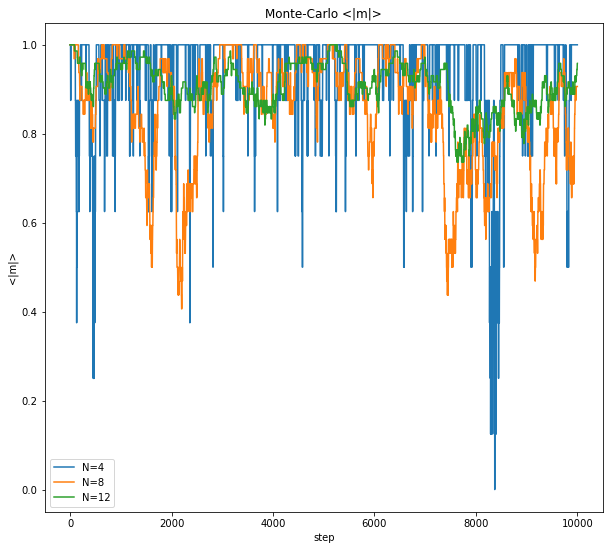

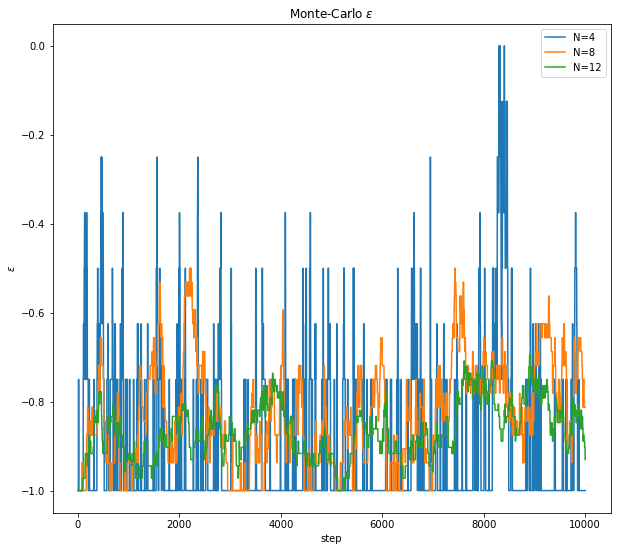

In [130]:
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(N_4[0], label='N=4')
ax.plot(N_8[0], label='N=8')
ax.plot(N_12[0], label='N=12')
ax.legend()
ax.set_ylabel('<m>')
ax.set_xlabel('step')
ax.set_title('Monte-Carlo <m>')
plt.show()
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(N_4[1], label='N=4')
ax.plot(N_8[1], label='N=8')
ax.plot(N_12[1], label='N=12')
ax.set_ylabel('<|m|>')
ax.set_xlabel('step')
ax.legend()
ax.set_title('Monte-Carlo <|m|>')
plt.show()
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(N_4[2], label='N=4')
ax.plot(N_8[2], label='N=8')
ax.plot(N_12[2], label='N=12')
ax.set_ylabel('$\epsilon$')
ax.set_xlabel('step')
ax.legend()
ax.set_title('Monte-Carlo $\epsilon$')
plt.show()

In [132]:
# Mean values 
print('<m>',N_4[0].mean(),N_8[0].mean(),N_12[0].mean())
print('<|m|>',N_4[1].mean(),N_8[1].mean(),N_12[1].mean())
print('energie',N_4[2].mean(),N_8[2].mean(),N_12[2].mean())


<m> 0.64125 0.85915625 0.9083805555555555
<|m|> 0.942375 0.85915625 0.9083805555555555
energie -0.9049875 -0.8301 -0.8668930555555555


We are in the broken phase. Therefore we expect most of the results at 1 or a total flip to -1 for m and 1 for |m|. We see  that a complete flip is not likely, but if we wait long enough, we have the same numbers of fluctuatiton around 1 as around -1.

# 5.3 Slow Tunneling Means Long Autocorrelation Times

In [133]:
# from lecture

def normalized_autocorrelation_function(timeseries, mean=None, until=None, fast=False):
    steps = len(timeseries)
    if mean is None:
        mean = timeseries.mean()
    series = timeseries-mean

    if fast:
        C = np.fft.ifft(np.fft.fft(series) * np.fft.ifft(series)).real
        # You showed why in exercise 4.3
    else:
        C = np.zeros_like(timeseries)
        C[0] = (series * series).mean()
        for dt in range(1, steps-1):
            C[dt] = (series[:-dt]*series[dt:]).mean()

    if until is None:
        return C / C[0]
    else:
        return C[:until] / C[0]

def  autocorrelation_time(timeseries):
    gamma = normalized_autocorrelation_function(timeseries)
    for x in range(len(gamma)):
        if gamma[0] >0:
            if gamma[x]<0:
                stop= x-1
                break
        else:
            if gamma[x]>0:
                stop= x-1
                break
    
    tau = 1/2 +gamma[:stop].sum()
    return tau


In [134]:

tau_m =[autocorrelation_time(N_4[0]),autocorrelation_time(N_8[0]),autocorrelation_time(N_12[0])]
tau_m_abs =[autocorrelation_time(N_4[1]),autocorrelation_time(N_8[1]),autocorrelation_time(N_12[1])]
tau_eps =[autocorrelation_time(N_4[2]),autocorrelation_time(N_8[2]),autocorrelation_time(N_12[2])]
# Noch zu beantworten: Do the results comport with the Monte Carlo history figure you made?

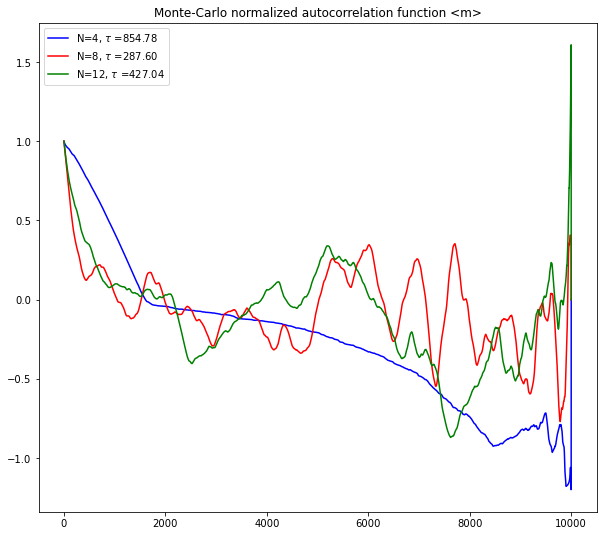

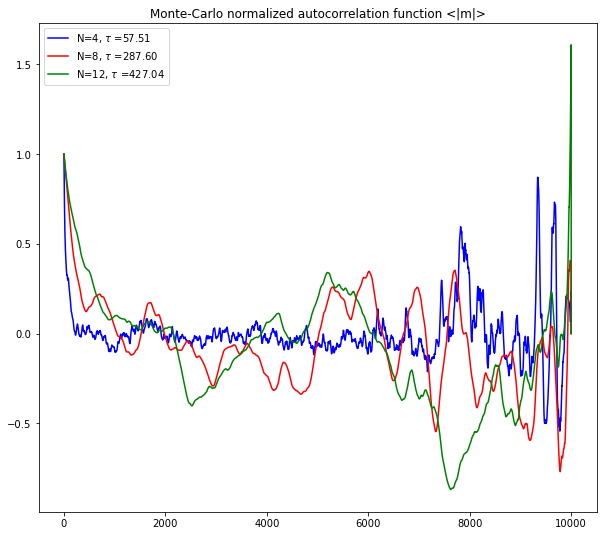

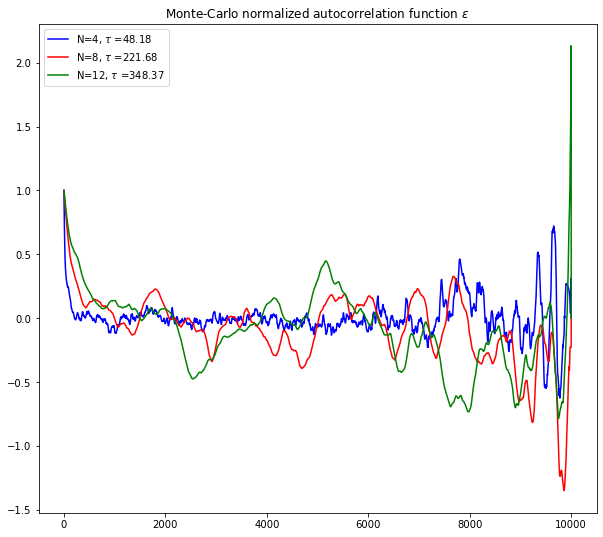

In [136]:
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(normalized_autocorrelation_function(N_4[0]), label=fr'N=4, $\tau$ ={tau_m[0]:.2f} ',color ='blue')
ax.plot(normalized_autocorrelation_function(N_8[0]), label=fr'N=8, $\tau$ ={tau_m[1]:.2f} ', color ='red')
ax.plot(normalized_autocorrelation_function(N_12[0]), label=fr'N=12, $\tau$ ={tau_m[2]:.2f} ', color ='green')
ax.legend()
ax.set_title('Monte-Carlo normalized autocorrelation function <m>')
plt.show()
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(normalized_autocorrelation_function(N_4[1]), label=fr'N=4, $\tau$ ={tau_m_abs[0]:.2f} ',color ='blue')
ax.plot(normalized_autocorrelation_function(N_8[1]), label=fr'N=8, $\tau$ ={tau_m_abs[1]:.2f} ', color ='red')
ax.plot(normalized_autocorrelation_function(N_12[1]), label=fr'N=12, $\tau$ ={tau_m_abs[2]:.2f} ', color ='green')
ax.legend()
ax.legend()
ax.set_title('Monte-Carlo normalized autocorrelation function <|m|>')
plt.show()
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(normalized_autocorrelation_function(N_4[2]), label=fr'N=4, $\tau$ ={tau_eps[0]:.2f} ',color ='blue')
ax.plot(normalized_autocorrelation_function(N_8[2]), label=fr'N=8, $\tau$ ={tau_eps[1]:.2f} ', color ='red')
ax.plot(normalized_autocorrelation_function(N_12[2]), label=fr'N=12, $\tau$ ={tau_eps[2]:.2f} ', color ='green')
ax.legend()
ax.legend()
ax.set_title('Monte-Carlo normalized autocorrelation function $\epsilon$ ')
plt.show()

# Write 1 or 2 sentences explaining why the very slow autocorrelation time of m is not important.

Because we have an option to do another run with $-\sigma$...

# 5.4 The Thermodynamic Limit for One J

In [137]:
# First throw away the first 3*𝜏 samples and calculate 𝜏 again from max tau_epsilon/ tau_|m|


In [138]:
tau_boot=[max(int(autocorrelation_time(N_4[1][3*int(tau_m_abs[0]):])),int(autocorrelation_time(N_4[1][3*int(tau_eps[0]):])))                    
                    ,max(int(autocorrelation_time(N_8[1][3*int(tau_m_abs[1]):])),int(autocorrelation_time(N_8[1][3*int(tau_m_abs[1]):])))
                ,max(int(autocorrelation_time(N_12[1][3*int(tau_m_abs[2]):])),int(autocorrelation_time(N_12[1][3*int(tau_m_abs[2]):])))]

In [143]:
print(tau_boot)

[58, 285, 394]


In [140]:
def bootstrap(sample,size, steps):
    mean = np.zeros(steps)
    uncert = np.zeros(steps)
    for i in range(steps):
        
        # choose random sample of length tau
        y = random.sample(sample.tolist(), size)
        
        mean[i] = np.mean(y)
        uncert[i] = np.std(y)
    m = mean.mean()
    u = uncert.std()
    return m,u

In [169]:
# mean, uncertainties for |m|
m_4,u_4 = bootstrap(N_4[1][3*int(tau_boot[0]):],tau_boot[0],5000)
m_8,u_8 = bootstrap(N_8[1][3*int(tau_boot[1]):],tau_boot[1],5000)
m_12,u_12 = bootstrap(N_12[1][3*int(tau_boot[2]):],tau_boot[2],5000)

m_abs_boot = [m_4,m_8,m_12] 
u_abs_boot = [u_4,u_8, u_12]

one_over_n2 = np.array([1/4**2,1/8**2, 1/12**2])


em_4,eu_4 = bootstrap(N_4[2][3*int(tau_boot[0]):],tau_boot[0],5000)
em_8,eu_8 = bootstrap(N_8[2][3*int(tau_boot[1]):],tau_boot[1],5000)
em_12,eu_12 = bootstrap(N_12[2][3*int(tau_boot[2]):],tau_boot[2],5000)

e_boot = [em_4,em_8,em_12] 
e_boot = [eu_4,eu_8, eu_12]



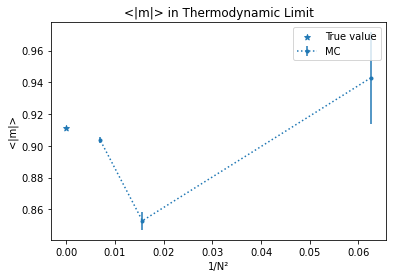

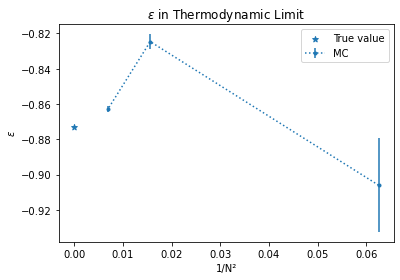

In [189]:
plt.errorbar(one_over_n2,m_abs_boot, yerr = u_abs_boot,marker ='.', linestyle=':', label = 'MC')
plt.ylabel('<|m|>')
plt.xlabel('1/N²')
plt.scatter(0,m([0.5]), label='True value', marker = '*')
plt.title('<|m|> in Thermodynamic Limit')
plt.legend()
plt.show()

plt.errorbar(one_over_n2,em_abs_boot, yerr = eu_abs_boot,marker ='.', linestyle=':', label = 'MC')
plt.ylabel('$\epsilon$')
plt.xlabel('1/N²')
plt.title('$\epsilon$ in Thermodynamic Limit')
plt.scatter(0,epsilon(0.5), label='True value', marker = '*')
plt.legend()
plt.show()

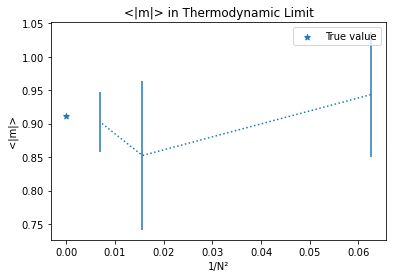

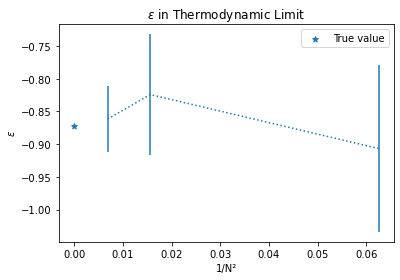

In [188]:
#from lecture

def block(timeseries, stride, weights=None):
    # Assumes timeseries is 1D.
    # stride = typically the autocorrelation time
    # weights = None is the importance-sampling case

    if weights is None:
        default_weights = True
        weights = np.ones_like(timeseries)
    else:
        default_weights = False

    weighted = timeseries * weights

    # If the stride doesn't evenly divide the timeseries we need to drop some.
    remainder = len(weighted) % stride
    # I drop from the front, but that's a choice.
    # It has a small effect on the numerical results you'll get but if you've got enough statistics, no problem.
    averaged = weighted[remainder:].reshape(-1, stride).mean(axis=-1)
    new_weights = weights[remainder:].reshape(-1, stride).mean(axis=-1)

    if default_weights:
        return averaged
    else:
        return averaged, new_weights
    
block_4 =block(N_4[1][3*int(tau_boot[0]):],tau_boot[0])
block_8 =block(N_8[1][3*int(tau_boot[1]):],tau_boot[1])
block_12 =block(N_12[1][3*int(tau_boot[2]):],tau_boot[2])

m_abs_block =[block_4.mean(),block_8.mean(),block_12.mean()] 
u_abs_block =[block_4.std(),block_8.std(), block_12.std()]

eblock_4 =block(N_4[2][3*int(tau_boot[0]):],tau_boot[0])
eblock_8 =block(N_8[2][3*int(tau_boot[1]):],tau_boot[1])
eblock_12 =block(N_12[2][3*int(tau_boot[2]):],tau_boot[2])

e_block =[eblock_4.mean(),eblock_8.mean(),eblock_12.mean()] 
u_e_block =[eblock_4.std(),eblock_8.std(), eblock_12.std()]

plt.errorbar(one_over_n2,m_abs_block, yerr = u_abs_block , linestyle = ':')
plt.ylabel('<|m|>')
plt.xlabel('1/N²')
plt.scatter(0,m([0.5]), label='True value', marker = '*')
plt.title('<|m|> in Thermodynamic Limit')
plt.legend()
plt.show()

plt.errorbar(one_over_n2,e_block, yerr = u_e_block, linestyle = ':')
plt.ylabel('$\epsilon$')
plt.xlabel('1/N²')
plt.scatter(0,epsilon(0.5), label='True value', marker = '*')
plt.title('$\epsilon$ in Thermodynamic Limit')
plt.legend()
plt.show()

# Explain what you see